<a href="https://www.kaggle.com/code/mdforhadmia/weather-forcasting-using-machine-learning?scriptVersionId=310644048" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:

df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")
print(df.head())

   Year  Month  Temperature  Precipitation
0  1901      1      16.9760        18.5356
1  1901      2      19.9026        16.2548
2  1901      3      24.3158        70.7981
3  1901      4      28.1834        66.1616
4  1901      5      27.8892       267.2150


In [3]:
# Month cyclic features
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Features
X = df[['Year', 'Month_sin', 'Month_cos']]
y_temp = df['Temperature']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_temp, test_size=0.2, random_state=42
)


# **Linear Regression ******# 

In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = lr_model.predict(X_test)

In [7]:
r2_temp = r2_score(y_test, y_pred)
print("Temperature R² Score :", r2_temp)

Temperature R² Score : 0.7863120342514709


Temperature : Linear regression model 
**R2 score : 0.78   Accuracy : 78%**


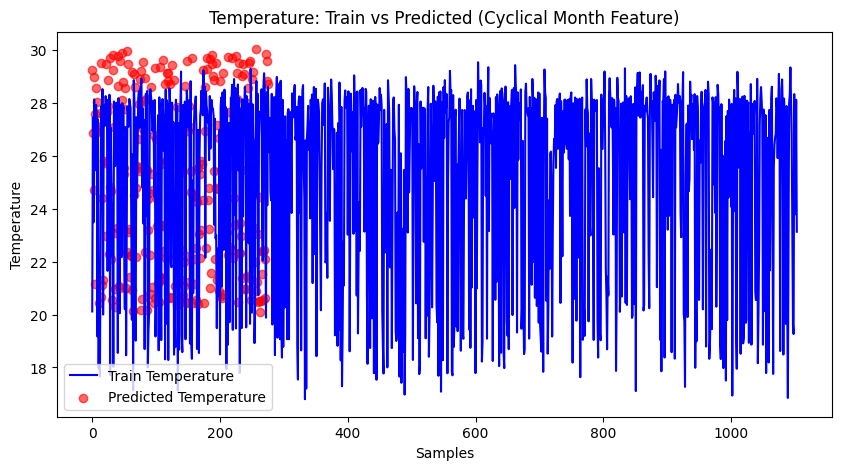

In [8]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_train)), y_train.values, label="Train Temperature", color="blue")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Temperature", color="red", alpha=0.6)
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.title("Temperature: Train vs Predicted (Cyclical Month Feature)")
plt.legend()
plt.show()

# Precipitation Prediction : 

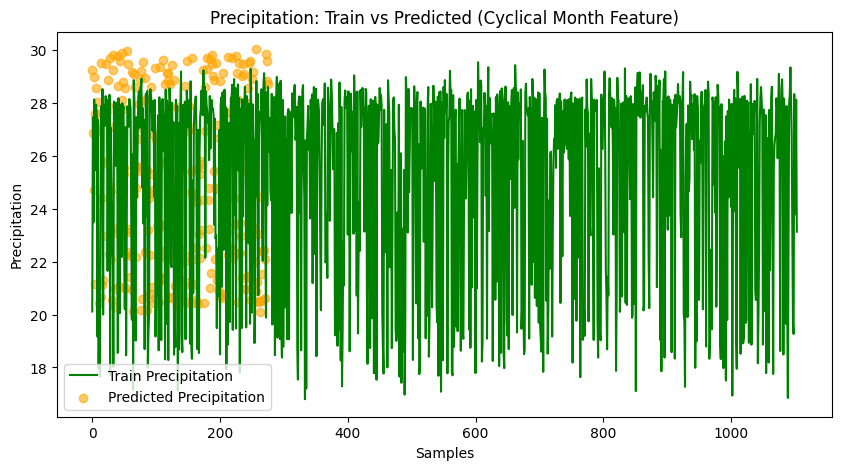

In [9]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_train)), y_train.values, label="Train Precipitation", color="green")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Precipitation", color="orange", alpha=0.6)
plt.xlabel("Samples")
plt.ylabel("Precipitation")
plt.title("Precipitation: Train vs Predicted (Cyclical Month Feature)")
plt.legend()
plt.show()

In [10]:
r2_prec = r2_score(y_test, y_pred)
print("Precipitation R² Score ):", r2_prec)

Precipitation R² Score ): 0.7863120342514709



# Precipitation R2 Score : 0.87
# accuracy : 87%


In [11]:
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Sort for time series
df = df.sort_values(by=['Year', 'Month'])

# Month cyclic features
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Lag + Rolling features (🔥 accuracy booster)
df['Prec_lag1'] = df['Precipitation'].shift(1)
df['Prec_roll3'] = df['Precipitation'].rolling(3).mean()

# Drop NaN
df = df.dropna()

# Features
X = df[['Year', 'Month_sin', 'Month_cos', 'Prec_lag1', 'Prec_roll3']]
y_prec = df['Precipitation']

In [12]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y_prec[:train_size]
y_test = y_prec[train_size:]

# Apply Random Forest Regressor


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=300,     # more trees = better learning
    max_depth=10,         # control overfitting
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [14]:
y_pred = rf_model.predict(X_test)

In [15]:
from sklearn.metrics import r2_score

r2_prec = r2_score(y_test, y_pred)
accuracy_prec = r2_prec * 100

print("Precipitation R² Score:", r2_prec)
print("Precipitation Accuracy (%):", accuracy_prec)

Precipitation R² Score: 0.8854351673105687
Precipitation Accuracy (%): 88.54351673105687


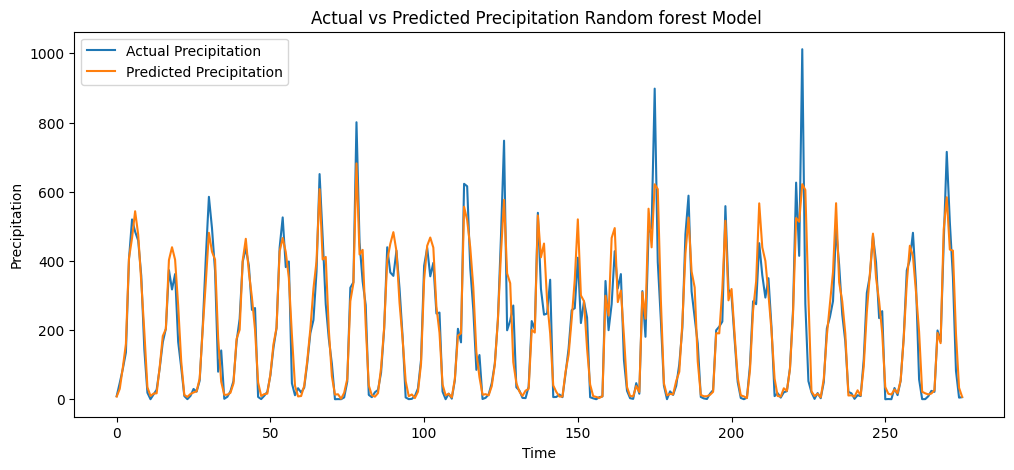

In [16]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual Precipitation")
plt.plot(y_pred, label="Predicted Precipitation")

plt.xlabel("Time")
plt.ylabel("Precipitation")
plt.title("Actual vs Predicted Precipitation Random forest Model ")
plt.legend()
plt.show()

In [17]:
# last known values use 
last_row = df.iloc[-1]

future = [[
    2020,
    np.sin(2*np.pi*6/12),
    np.cos(2*np.pi*6/12),
    last_row['Precipitation'],
    last_row['Prec_roll3']         
]]

future_prec = rf_model.predict(future)
print("Future Precipitation (June 2020):", future_prec[0])

Future Precipitation (June 2020): 62.43148032447092


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


> Apply random Forest Regressor Model For Temperature

In [18]:
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Sort for time series
df = df.sort_values(by=['Year', 'Month'])

# Month cyclic
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Lag + Rolling (Temperature)
df['Temp_lag1'] = df['Temperature'].shift(1)
df['Temp_roll3'] = df['Temperature'].rolling(3).mean()

# Lag + Rolling (Precipitation)
df['Prec_lag1'] = df['Precipitation'].shift(1)
df['Prec_roll3'] = df['Precipitation'].rolling(3).mean()

# Drop NaN
df = df.dropna()

In [19]:
X = df[['Year', 'Month_sin', 'Month_cos',
        'Temp_lag1', 'Temp_roll3',
        'Prec_lag1', 'Prec_roll3']]

y_temp = df['Temperature']
y_prec = df['Precipitation']

In [20]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train_temp = y_temp[:train_size]
y_test_temp = y_temp[train_size:]

y_train_prec = y_prec[:train_size]
y_test_prec = y_prec[train_size:]

In [21]:
from sklearn.ensemble import RandomForestRegressor

temp_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

temp_model.fit(X_train, y_train_temp)
temp_pred = temp_model.predict(X_test)

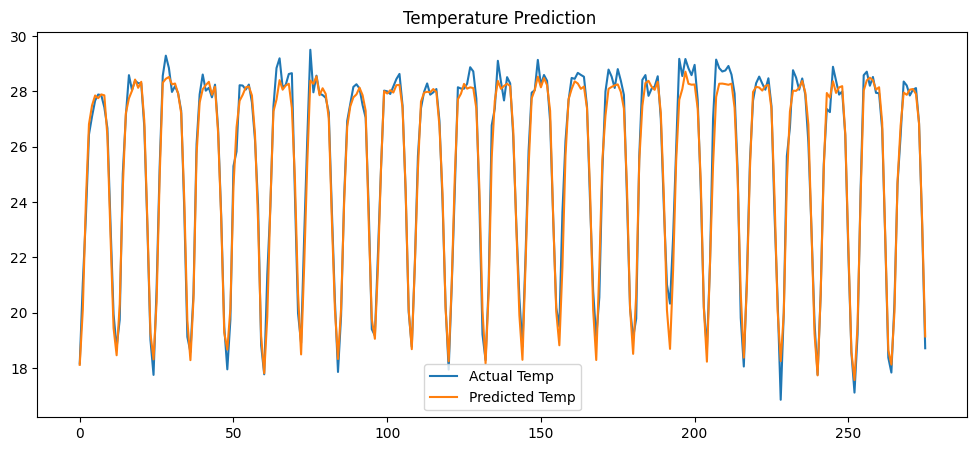

In [22]:
plt.figure(figsize=(12,5))
plt.plot(y_test_temp.values, label="Actual Temp")
plt.plot(temp_pred, label="Predicted Temp")
plt.title("Temperature Prediction ")
plt.legend()
plt.show()

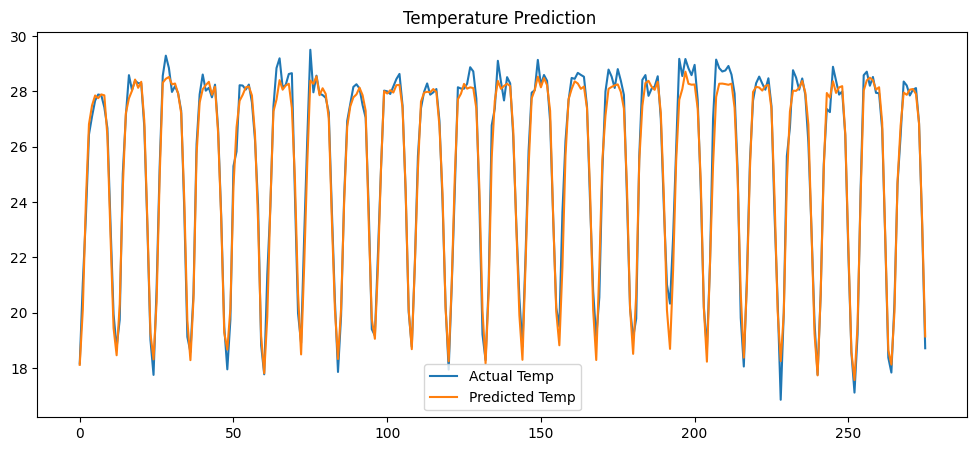

In [23]:
plt.figure(figsize=(12,5))
plt.plot(y_test_temp.values, label="Actual Temp")
plt.plot(temp_pred, label="Predicted Temp")
plt.title("Temperature Prediction ")
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import r2_score

r2_temp = r2_score(y_test_temp, temp_pred)
acc_temp = r2_temp * 100

print("Temperature R²:", r2_temp)
print("Temperature Accuracy :", acc_temp)

Temperature R²: 0.9815049839148012
Temperature Accuracy : 98.15049839148013


**Now apply LSTM**

In [25]:
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
        
    return np.array(Xs), np.array(ys)

In [26]:
# numpy array 
X_values = X.values
y_values = df[['Temperature', 'Precipitation']].values

# sequence 
X_seq, y_seq = create_sequences(X_values, y_values, time_steps=3)

print(X_seq.shape)  # (samples, timesteps, features)

(1375, 3, 7)


In [27]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))

model.add(Dense(2))

model.compile(optimizer='adam', loss='mse')

2026-04-11 03:27:39.186025: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775878059.354586      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775878059.401363      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775878059.817393      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775878059.817432      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775878059.817434      16 computation_placer.cc:177] computation placer alr

In [29]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 43999.8516 - val_loss: 37410.7031
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 42505.2891 - val_loss: 36581.0234
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40576.4023 - val_loss: 36033.8047
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37858.2383 - val_loss: 35688.3906
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40014.9375 - val_loss: 35396.2773
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39348.0742 - val_loss: 35130.7891
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40182.9336 - val_loss: 34878.4961
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41046.7578 - val_loss: 34639.1211
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36920.2930 - val_loss: 34412.2188
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36093.5977 - val_loss: 34188.2070
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41330.8203 - val_lo

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [31]:
df = pd.read_csv("/kaggle/input/datasets/mdforhadmia/temp-and-rain-csv/Temp_and_rain.csv")

# Sort data (VERY IMPORTANT)
df = df.sort_values(by=['Year', 'Month'])

In [32]:
# Month cyclical encoding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Select features
features = ['Year', 'Month_sin', 'Month_cos']
target = ['Temperature', 'Precipitation']

X = df[features]
y = df[target]

In [33]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [34]:
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
        
    return np.array(Xs), np.array(ys)

In [35]:
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps=6)

print("Shape:", X_seq.shape)

Shape: (1374, 6, 3)


In [36]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [37]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))

model.add(Dense(2)) 

model.compile(optimizer='adam', loss='mse')

In [38]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1360 - val_loss: 0.0170
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0154 - val_loss: 0.0146
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0129 - val_loss: 0.0129
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - val_loss: 0.0132
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0107 - val_loss: 0.0112
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0095 - val_loss: 0.0095
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - val_loss: 0.0080
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0064 - val_loss: 0.0062
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0066
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 - val_l

In [39]:
y_pred = model.predict(X_test)

# Inverse transform (IMPORTANT)
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [40]:
r2_temp = r2_score(y_test_inv[:,0], y_pred_inv[:,0])
r2_prec = r2_score(y_test_inv[:,1], y_pred_inv[:,1])

print("Temperature R2:", r2_temp)
print("Precipitation R2:", r2_prec)

Temperature R2: 0.9628026251752901
Precipitation R2: 0.7938878060094965


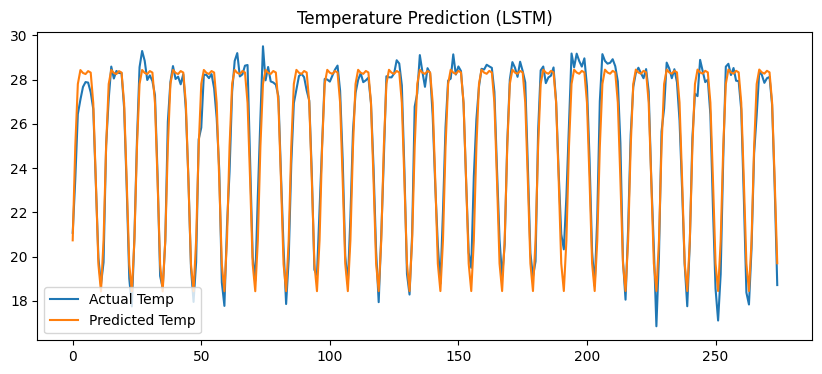

In [41]:
plt.figure(figsize=(10,4))

plt.plot(y_test_inv[:,0], label="Actual Temp")
plt.plot(y_pred_inv[:,0], label="Predicted Temp")

plt.title("Temperature Prediction (LSTM)")
plt.legend()
plt.show()

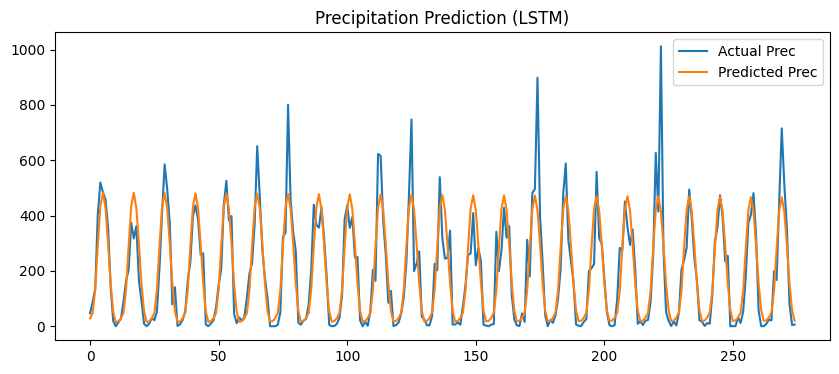

In [42]:
plt.figure(figsize=(10,4))

plt.plot(y_test_inv[:,1], label="Actual Prec")
plt.plot(y_pred_inv[:,1], label="Predicted Prec")

plt.title("Precipitation Prediction (LSTM)")
plt.legend()
plt.show()

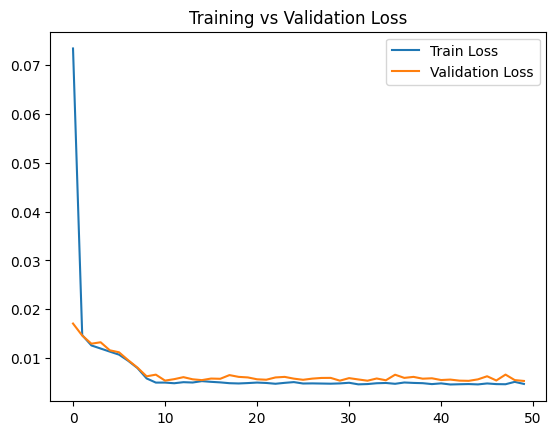

In [43]:
plt.figure()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [44]:
# Last sequence
last_seq = X_scaled[-3:]

last_seq = last_seq.reshape(1, 3, X.shape[1])

future_pred = model.predict(last_seq)
future_pred = scaler_y.inverse_transform(future_pred)

print("Future Temperature:", future_pred[0][0])
print("Future Precipitation:", future_pred[0][1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Future Temperature: 18.974844
Future Precipitation: 5.913196
